# Goalkeeper Saves and Clean Sheets- FIFA World Cup 2026

**An analytic task driven by a distinct question that will be answered using all the following skills:**

1. Analytic question formulation
2. Data wrangling
3. Data preparation and sampling
4. Descriptive statistics
5. Inferential statistics (Confidence interval)
6. Inferential statistics (Two-sample t-Test)

## 1. Analytic Question Formulation

**Is there a significant difference in the average number of goalkeeper saves per match between teams that recorded zero clean sheets and teams that recorded one or more clean sheets during the FIFA World Cup 2026?**

This question was chosen because it's genuinely unclear which way it would go - a clean sheet could mean the defense was so strong the keeper barely had to work, or it could mean the keeper made lots of saves to protect the shutout. Both stories make sense, so the data actually has to decide. The two groups (zero vs. one-or-more clean sheets) already exist naturally in the data, saves and clean sheets are easy to measure with no guesswork, and the setup fits perfectly with a two-sample t-test and confidence interval - exactly the tools required for this project.

## 2. Data Wrangling

**Data source:** `GOALKEEPERSAVESPERMATCH.xlsx` — team-level FIFA World Cup 2026 statistics (48 teams, expanded tournament format), covering:
- `TEAM` — country name
- `MATCHES PLAYED` — total matches played in the tournament
- `GOALKEEPER SAVES` — total goalkeeper saves across all matches
- `CLEAN SHEETS` — number of matches with zero goals conceded
- `GOALKEEPER SAVES PER MATCH` — derived rate (saves ÷ matches played)
- `CLEAN-SHEET GROUP` — pre-labeled grouping variable (`ZERO` / `ONE OR MORE`)

We load the raw file, standardize column names, verify data types, and check for missing values, duplicates before analysis.

Datasets are taken from the following link:
- FIFA Official Website: https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics
- The Stats Don't Lie: https://www.thestatsdontlie.com/football/world-cup-2026/
- FB Ref: https://fbref.com/en/

In [99]:
# Imports
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [100]:
# Load raw data
raw = pd.read_excel("GOALKEEPERSAVESPERMATCH.xlsx")
print("Raw shape:", raw.shape)
raw.head()

Raw shape: (48, 6)


,TEAM,MATCHES PLAYED,GOALKEEPER SAVES,CLEAN SHEETS,GOALKEEPER SAVES PER MATCH,CLEAN-SHEET GROUP
0,ALGERIA,4,9,0,2.250000,ZERO
1,ARGENTINA,8,20,2,2.500000,ONE OR MORE
2,AUSTRALIA,4,14,2,3.500000,ONE OR MORE
3,AUSTRIA,4,15,0,3.750000,ZERO
4,BELGIUM,6,19,1,3.166667,ONE OR MORE


In [101]:
# Standardize column names (lowercase) for easier handling in code
df = raw.copy()
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)
print(df.columns.tolist())
df.head()

['team', 'matches_played', 'goalkeeper_saves', 'clean_sheets', 'goalkeeper_saves_per_match', 'clean_sheet_group']


,team,matches_played,goalkeeper_saves,clean_sheets,goalkeeper_saves_per_match,clean_sheet_group
0,ALGERIA,4,9,0,2.250000,ZERO
1,ARGENTINA,8,20,2,2.500000,ONE OR MORE
2,AUSTRALIA,4,14,2,3.500000,ONE OR MORE
3,AUSTRIA,4,15,0,3.750000,ZERO
4,BELGIUM,6,19,1,3.166667,ONE OR MORE


In [102]:
# Data quality checks
print("Missing values per column:")
print(df.isnull().sum())

print("\nDuplicate team entries:", df["team"].duplicated().sum())

print("\nData types:")
print(df.dtypes)

print("\nAny non-positive matches played?", (df["matches_played"] <= 0).any())
print("Any clean_sheets exceeding matches_played (logical error)?",
      (df["clean_sheets"] > df["matches_played"]).any())

Missing values per column:
team                          0
matches_played                0
goalkeeper_saves              0
clean_sheets                  0
goalkeeper_saves_per_match    0
clean_sheet_group             0
dtype: int64

Duplicate team entries: 0

Data types:
team                           object
matches_played                  int64
goalkeeper_saves                int64
clean_sheets                    int64
goalkeeper_saves_per_match    float64
clean_sheet_group              object
dtype: object

Any non-positive matches played? False
Any clean_sheets exceeding matches_played (logical error)? False


In [103]:
# Final wrangled dataset 
df_clean = df[["team", "matches_played", "goalkeeper_saves", "clean_sheets",
               "goalkeeper_saves_per_match", "clean_sheet_group"]].copy()
df_clean = df_clean.sort_values("team").reset_index(drop=True)
df_clean.to_csv("GOALKEEPERSAVESPERMATCH_CLEAN.csv", index=False)
print(df_clean.shape)
df_clean

(48, 6)


,team,matches_played,goalkeeper_saves,clean_sheets,goalkeeper_saves_per_match,clean_sheet_group
0,ALGERIA,4,9,0,2.250000,ZERO
1,ARGENTINA,8,20,2,2.500000,ONE OR MORE
2,AUSTRALIA,4,14,2,3.500000,ONE OR MORE
3,AUSTRIA,4,15,0,3.750000,ZERO
4,BELGIUM,6,19,1,3.166667,ONE OR MORE
5,BOSNIA,4,8,0,2.000000,ZERO
6,BRAZIL,5,15,2,3.000000,ONE OR MORE
7,CABO VERDE,4,18,2,4.500000,ONE OR MORE
8,CANADA,5,7,2,1.400000,ONE OR MORE
9,COLOMBIA,5,7,4,1.400000,ONE OR MORE


# 3. Data Preparation and Sampling 

**Population:** All 48 teams that competed in the FIFA World Cup 2026.


**Sampling:**
Teams were split into two groups based on clean-sheet status —
21 teams with zero clean sheets, and 27 teams with one or more clean sheets. A stratified random sample of 36 teams (75%) was drawn from the 48 eligible teams:
* 16 randomly selected from the 21 zero-clean-sheet teams
* 20 randomly selected from the 27 one-or-more-clean-sheet teams

Each sampled team yields one observation — that team's average goalkeeper saves per match across the tournament — used to compare the two clean-sheet groups.

In [104]:
# Create the stratified sample without overwriting df_clean
zero_group = df_clean[df_clean["clean_sheet_group"] == "Zero clean sheets"].copy()
one_or_more_group = df_clean[df_clean["clean_sheet_group"] == "One or more clean sheets"].copy()

# Normalize labels before filtering
group_labels = df_clean["clean_sheet_group"].astype(str).str.strip().str.upper()

zero_group = df_clean.loc[group_labels == "ZERO"].copy()
one_or_more_group = df_clean.loc[group_labels == "ONE OR MORE"].copy()

if len(zero_group) < 16 or len(one_or_more_group) < 20:
    raise ValueError("Insufficient rows in one or both clean-sheet groups.")

df_stratified = pd.concat(
    [
        zero_group.sample(n=16, random_state=42),
        one_or_more_group.sample(n=20, random_state=42),
    ],
    ignore_index=True
)

df_stratified["clean_sheet_group"] = df_stratified["clean_sheet_group"].map({
    "ZERO": "Zero clean sheets",
    "ONE OR MORE": "One or more clean sheets"
})

# Keep rows sorted by team for readability
df_stratified = df_stratified.sort_values("team").reset_index(drop=True)

print(df_stratified["clean_sheet_group"].value_counts())
print("\nZero clean sheet teams in sample:", (df_stratified["clean_sheet_group"] == "Zero clean sheets").sum())
print("One or more clean sheet teams in sample:", (df_stratified["clean_sheet_group"] == "One or more clean sheets").sum())
df_stratified.head()

clean_sheet_group
One or more clean sheets    20
Zero clean sheets           16
Name: count, dtype: int64

Zero clean sheet teams in sample: 16
One or more clean sheet teams in sample: 20


,team,matches_played,goalkeeper_saves,clean_sheets,goalkeeper_saves_per_match,clean_sheet_group
0,ALGERIA,4,9,0,2.250000,Zero clean sheets
1,ARGENTINA,8,20,2,2.500000,One or more clean sheets
2,AUSTRALIA,4,14,2,3.500000,One or more clean sheets
3,AUSTRIA,4,15,0,3.750000,Zero clean sheets
4,BELGIUM,6,19,1,3.166667,One or more clean sheets


# 4. Descriptive Statistics

In [111]:
group0 = df_clean.loc[df_clean.clean_sheet_group == "Zero clean sheets", "goalkeeper_saves_per_match"]
group1 = df_clean.loc[df_clean.clean_sheet_group == "One or more clean sheets", "goalkeeper_saves_per_match"]

desc = df_clean.groupby("clean_sheet_group")["goalkeeper_saves_per_match"].agg(
    n="count", mean="mean", median="median", std="std",
    min="min", max="max",
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75)
).round(3)

desc

,n,mean,median,std,min,max,q1,q3
clean_sheet_group,,,,,,,,
ONE OR MORE,27,3.346,3.167,1.365,1.400,7.000,2.625,4.00
ZERO,21,3.153,3.333,0.998,1.333,5.333,2.333,3.75


In [117]:
print(f"Mean difference (Zero - One or more): {group0.mean() - group1.mean():.3f} saves/match")
print(f"Overall sample mean (all 48 teams): {df_clean['goalkeeper_saves_per_match'].mean():.3f}")
print(f"Overall sample std:  {df_clean['goalkeeper_saves_per_match'].std():.3f}")

Mean difference (Zero - One or more): -0.193 saves/match
Overall sample mean (all 48 teams): 3.261
Overall sample std:  1.210


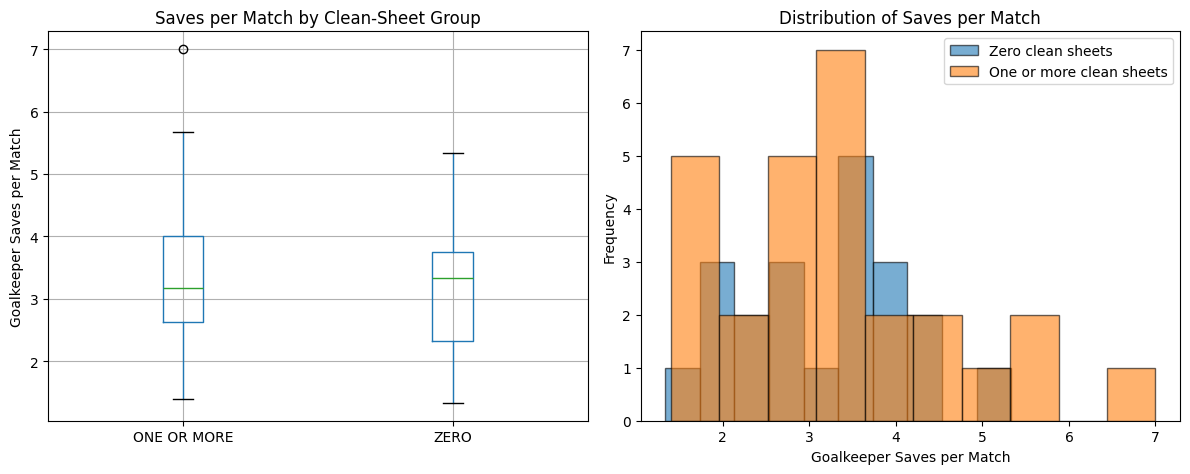

In [122]:
#  Visualization: boxplot comparing the two groups 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df_clean.boxplot(column="goalkeeper_saves_per_match", by="clean_sheet_group", ax=axes[0])
axes[0].set_title("Saves per Match by Clean-Sheet Group")
axes[0].set_xlabel("")
axes[0].set_ylabel("Goalkeeper Saves per Match")
plt.suptitle("")

axes[1].hist(group0, alpha=0.6, label="Zero clean sheets", bins=10, edgecolor="black")
axes[1].hist(group1, alpha=0.6, label="One or more clean sheets", bins=10, edgecolor="black")
axes[1].set_title("Distribution of Saves per Match")
axes[1].set_xlabel("Goalkeeper Saves per Match")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.savefig("descriptive_plots.png", dpi=150)
plt.show()

## 5. Inferential Statistics — 95% Confidence Interval

We compute a 95% confidence interval for the **difference in population means** (Zero clean sheets − One or more clean sheets), using Welch's method (does not assume equal variances between the two groups — the safer default when group sizes and standard deviations differ).

In [126]:
n0, n1 = len(group0), len(group1)
m0, m1 = group0.mean(), group1.mean()
s0, s1 = group0.std(ddof=1), group1.std(ddof=1)

diff = m0 - m1
# Rebuild groups using the actual normalized labels in df_clean
group0 = df_clean.loc[df_clean["clean_sheet_group"].str.upper() == "ZERO", "goalkeeper_saves_per_match"]
group1 = df_clean.loc[df_clean["clean_sheet_group"].str.upper() == "ONE OR MORE", "goalkeeper_saves_per_match"]

n0, n1 = len(group0), len(group1)
m0, m1 = group0.mean(), group1.mean()
s0, s1 = group0.std(ddof=1), group1.std(ddof=1)

if n0 == 0 or n1 == 0:
    raise ValueError("One of the clean-sheet groups is empty. Check the clean_sheet_group labels.")

diff = m0 - m1
se = np.sqrt((s0**2 / n0) + (s1**2 / n1))

# Welch-Satterthwaite degrees of freedom
df_welch = (s0**2/n0 + s1**2/n1)**2 / (
    (s0**2/n0)**2/(n0-1) + (s1**2/n1)**2/(n1-1)
)

t_crit = stats.t.ppf(0.975, df_welch)
ci_low = diff - t_crit * se
ci_high = diff + t_crit * se

print(f"Group 0 (Zero clean sheets):        n={n0}, mean={m0:.3f}, sd={s0:.3f}")
print(f"Group 1 (One or more clean sheets): n={n1}, mean={m1:.3f}, sd={s1:.3f}")
print(f"\nDifference in means (Zero - One or more): {diff:.3f}")
print(f"Standard error of the difference:          {se:.3f}")
print(f"Welch-Satterthwaite degrees of freedom:     {df_welch:.2f}")
print(f"t-critical value (95%, two-tailed):         {t_crit:.3f}")
print(f"95% Confidence Interval for the difference: ({ci_low:.3f}, {ci_high:.3f})")

Group 0 (Zero clean sheets):        n=21, mean=3.153, sd=0.998
Group 1 (One or more clean sheets): n=27, mean=3.346, sd=1.365

Difference in means (Zero - One or more): -0.193
Standard error of the difference:          0.341
Welch-Satterthwaite degrees of freedom:     45.86
t-critical value (95%, two-tailed):         2.013
95% Confidence Interval for the difference: (-0.879, 0.494)


**Interpretation:** We are 95% confident the true difference in average goalkeeper saves per match between teams with zero clean sheets and teams with one or more clean sheets falls within this interval. If the interval contains 0, that tells us "no difference" is a plausible true value. 

## 6. Inferential Statistics — Two-Sample t-Test

We use an **independent (two-sample) t-test** rather than a one-sample test because we are comparing the means of two separate, independent groups of teams — not comparing one group's mean to a fixed benchmark value.

**Assumption checks** are run first (normality per group, and equality of variances), then the test itself.

In [129]:
# --- Assumption 1: Normality within each group (Shapiro-Wilk) ---
sw0 = stats.shapiro(group0)
sw1 = stats.shapiro(group1)
print(f"Shapiro-Wilk (Zero clean sheets):        W={sw0.statistic:.3f}, p={sw0.pvalue:.4f}")
print(f"Shapiro-Wilk (One or more clean sheets): W={sw1.statistic:.3f}, p={sw1.pvalue:.4f}")
print("(p > 0.05 in both suggests no strong evidence against normality)")

# --- Assumption 2: Equality of variances (Levene's test) ---
levene = stats.levene(group0, group1)
print(f"\nLevene's test for equal variances: stat={levene.statistic:.3f}, p={levene.pvalue:.4f}")
print("(p < 0.05 would suggest variances differ -> favors Welch's t-test, used below regardless as the safer default)")

Shapiro-Wilk (Zero clean sheets):        W=0.970, p=0.7252
Shapiro-Wilk (One or more clean sheets): W=0.937, p=0.1052
(p > 0.05 in both suggests no strong evidence against normality)

Levene's test for equal variances: stat=0.428, p=0.5161
(p < 0.05 would suggest variances differ -> favors Welch's t-test, used below regardless as the safer default)


In [131]:
# --- Two-sample t-test (Welch's, unequal variances) ---
t_stat, p_value = stats.ttest_ind(group0, group1, equal_var=False)

print(f"t-statistic: {t_stat:.3f}")
print(f"p-value:     {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"\nDecision: p < {alpha} -> REJECT H0. There IS a statistically significant difference.")
else:
    print(f"\nDecision: p >= {alpha} -> FAIL TO REJECT H0. No statistically significant difference detected.")

# --- Effect size: Cohen's d ---
pooled_sd = np.sqrt(((n0-1)*s0**2 + (n1-1)*s1**2) / (n0+n1-2))
cohens_d = diff / pooled_sd
print(f"\nCohen's d (effect size): {cohens_d:.3f}")

if abs(cohens_d) < 0.2:
    magnitude = "negligible"
elif abs(cohens_d) < 0.5:
    magnitude = "small"
elif abs(cohens_d) < 0.8:
    magnitude = "medium"
else:
    magnitude = "large"
print(f"Effect size magnitude: {magnitude}")

t-statistic: -0.564
p-value:     0.5753

Decision: p >= 0.05 -> FAIL TO REJECT H0. No statistically significant difference detected.

Cohen's d (effect size): -0.158
Effect size magnitude: negligible


## 7. Conclusion

**Summary of Findings**

This analysis examined whether goalkeeper saves per match differ significantly between
FIFA World Cup 2026 teams that recorded zero clean sheets and teams that recorded one or
more clean sheets. Across all 48 teams in the tournament, teams with zero clean sheets
averaged 3.15 saves per match (n=21, SD=1.00), while teams with one or more clean sheets
averaged 3.35 saves per match (n=27, SD=1.37) — a difference of just 0.19 saves in favor
of the clean-sheet group.

A Welch's two-sample t-test found this difference to be statistically insignificant,
t(45.86) = -0.564, p = 0.575, well above the α = 0.05 threshold. The 95% confidence
interval for the true difference in means, (-0.879, 0.494), contains zero, confirming
that "no difference" remains a fully plausible value. The effect size (Cohen's d = -0.158)
is negligible, meaning that even if a true difference exists, it is too small to be
practically meaningful.

**Interpretation**

We fail to reject the null hypothesis: there is no statistically significant difference
in average goalkeeper saves per match between teams that kept a clean sheet and teams
that did not, at this World Cup. Notably, the direction of the (non-significant) gap runs
counter to a simple intuition — clean-sheet teams averaged *slightly more* saves, not
fewer, suggesting that a shutout is not typically the product of an "easy," low-shot
match.

A more likely explanation is that clean sheets arise through two distinct and
counterbalancing pathways: some teams keep a clean sheet through disciplined defensive
structure that limits the opponent's shot volume (requiring fewer saves), while others
keep a clean sheet through standout individual goalkeeping under heavy pressure (requiring
many saves). Averaged across 48 teams, these two patterns likely offset one another,
producing a near-zero net difference. This also reflects the fact that a clean sheet is
fundamentally a team-level outcome — shaped by defensive organization, opponent quality,
and match context — rather than a outcome driven primarily by the goalkeeper's save count
alone.

**Limitations**

- **Statistical power:** with 21 and 27 teams per group, the sample is modest; a true
  small effect may exist but be undetectable at this sample size. "No significant
  difference" should be read as "not detectable here," not as proof the two groups are
  truly identical.
- **Measurement granularity:** saves-per-match does not distinguish routine saves from
  decisive, game-saving stops, which may mask meaningful differences in goalkeeping
  quality that a simple count cannot capture.
- **Population, not a random sample:** the 48 teams represent the entire tournament
  population rather than a sample drawn from a larger pool of "all possible World Cups,"
  so inference should be interpreted as describing this specific tournament's pattern
  rather than generalized to all future tournaments.
- **Non-causal:** this analysis establishes association (or lack thereof), not causation;
  no claim is made about saves *causing* clean sheets or vice versa.

**Overall**, the results suggest that at the FIFA World Cup 2026, a team's likelihood of
keeping a clean sheet was not meaningfully tied to how many saves its goalkeeper made —
reinforcing that clean sheets are better explained by broader defensive and tactical
factors than by shot-stopping volume alone.